# Does the answer survive on the orders that stayed delivered?

**Week 1, Monday, afternoon: the escalated case, alone, 35 minutes.** The six chapters answered
Meera on booked orders. Anand Iyer, the finance controller, has read the draft and pushes back:

> "Booked includes orders we cancelled and orders that came back. Do it again on what was
> delivered and stayed delivered, and tell me whether your answer survives."

**Who needs the answer.** Anand reads the note at the board and checks it against his books,
which keep what stayed delivered, and Meera signs the recommendation. An answer that holds only
on booked orders falls apart the first time Anand recomputes it, and the frequency
recommendation falls with it.

**The questions on the way.**

1. How many customers stand behind the delivered orders, and how often did each buy?
2. What does a typical delivered order look like?
3. How much more must delivered consumer revenue bring, and what would a discount do to it?
4. Which branch does Meera open first on delivered orders, once the window's edge is allowed for?
5. What one sentence does Meera sign on delivered orders?

The metrics at stake are the chapters' own, rebuilt on the delivered definition: orders per
customer, the typical order, the plan in rupees and the repeat picture. On the same 30 orders,
placed from 1 July to 26 September 2026, the chapters found 23 customers at 1.30 orders each, a
typical (median) order of Rs 2,205, a plan of Rs 9,722 more on the orders of the three consumer
segments, and, of the 16 one-time buyers, 9 too recent to judge against the median repeat gap of
45 days, so frequency came first and the Rs 12 crore waits for Tuesday's two quarters. This case
climbs the same questions on delivered orders, alone.

> **Kavya's review.** Rebuild it on delivered orders and say what moved and what held. If the
> branch changes on Anand's definition, Meera needs to know before Thursday.

Every placeholder is filled with the right option, and the notebook was executed from a fresh
kernel. Under each part sits why the other options fail. The nine TODO picks, in order, are
`cbdcaabbc`.

**Setup.** The first cell finds the shared helper, loads the 30 orders from `../data/`, and
turns every amount into a whole number with `int()`, the fix chapter 1 found for an amount
stored as text. `BOOKED` holds what the chapters found on booked orders, so the last table can
say what moved and what held.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

ORDERS = kit.load_records()

from datetime import date, timedelta
for order in ORDERS:
    order["amount"] = int(order["amount"])     # chapter 1's fix for an amount stored as text
end = date.fromisoformat(max(o["order_date"] for o in ORDERS))
BOOKED = {"orders per customer": 1.30, "typical order": 2205, "too recent": "9 of 16",
          "branch": "frequency"}              # what chapters 3 to 6 found on the 30 booked orders
print(len(ORDERS), "orders loaded; the extract ends on", end)

30 orders loaded; the extract ends on 2026-09-26


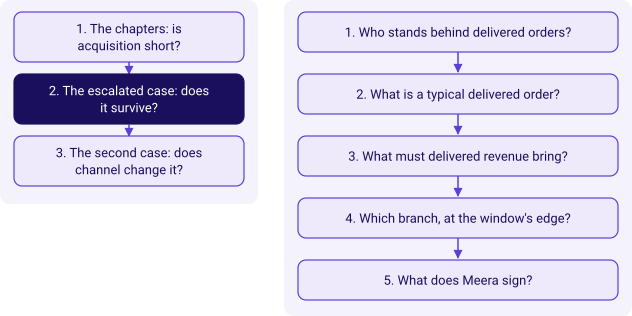

In [2]:
kit.side_by_side(
    kit.ladder(["The chapters: is acquisition short?", "The escalated case: does it survive?",
                "The second case: does channel change it?"], lit=1, show=False),
    kit.vflow(["1. Who stands behind delivered orders?", "2. What is a typical delivered order?",
               "3. What must delivered revenue bring?", "4. Which branch, at the window's edge?",
               "5. What does Meera sign?"], show=False),
)

## Part 1. How many customers stand behind the delivered orders, and how often did each buy?

A finance controller's definition changes every leaf of the tree, and at work the analyst
recounts the leaves on it before defending a recommendation.

**Write down:** delivered orders, delivered customers and delivered orders per customer.

leaf,booked (the chapters),delivered
orders,30,21
customers,23,19
orders per customer,1.30,1.11
revenue,"Rs 5,44,810","Rs 5,20,790"


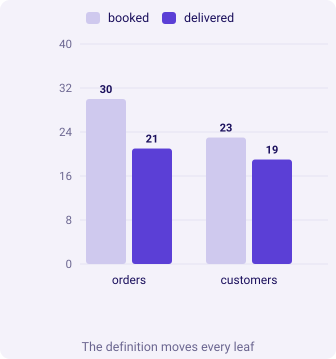

In [3]:
# TODO 1. Which condition keeps the orders that reached a customer and stayed there?
#   a) order["status"] != "cancelled"
#   b) order["status"] in ("delivered", "returned")
#   c) order["status"] == "delivered"
#   d) order["amount"] > 0
delivered, delivered_ids, delivered_revenue = [], [], 0
for order in ORDERS:
    if order["status"] == "delivered":
        delivered.append(order)
        delivered_ids.append(order["customer_id"])
        delivered_revenue += order["amount"]

# TODO 2. Which expression counts the distinct customers behind the delivered orders?
#   a) len(delivered_ids)
#   b) len(set(delivered_ids))
#   c) len(set(o["customer_id"] for o in ORDERS))
#   d) len(delivered)
delivered_customers = len(set(delivered_ids))

# TODO 3. Which expression is orders per customer on the delivered definition?
#   a) delivered_customers / len(delivered)
#   b) len(ORDERS) / delivered_customers
#   c) len(delivered) / 23
#   d) len(delivered) / delivered_customers
delivered_per_customer = len(delivered) / delivered_customers
kit.table(["leaf", "booked (the chapters)", "delivered"],
          [("orders", 30, len(delivered)), ("customers", 23, delivered_customers),
           ("orders per customer", f"{BOOKED['orders per customer']:.2f}", f"{delivered_per_customer:.2f}"),
           ("revenue", "Rs 5,44,810", kit.rupees(delivered_revenue))],
          caption="The same file on two definitions")
kit.columns(["orders", "customers"], [("booked", [30, 23]), ("delivered", [len(delivered), delivered_customers])],
            title="The definition moves every leaf")

In [4]:
kit.check("21 orders were delivered", len(delivered) == 21, len(delivered))
kit.check("delivered customers are fewer than delivered orders", delivered_customers < len(delivered))
kit.check("orders per customer times customers gives back the delivered orders",
          round(delivered_per_customer * delivered_customers) == len(delivered))

**Why not the others.** TODO 1: a keeps returns, which did not stay sold; b keeps them on
purpose, a different definition; d keeps everything. TODO 2: a counts rows; c counts booked
customers, mixing two definitions in one leaf; d counts orders. TODO 3: a is upside down; b puts
booked orders over delivered customers; c divides by the booked customer count.

**What happened.** 19 customers stand behind the 21 delivered orders, 1.11 orders each, with
Rs 5,20,790 delivered.

## Part 2. What does a typical delivered order look like?

A payback or a pricing case at work quotes a typical order, and it has to be the one the
definition in use leaves.

**Write down:** the delivered mean, the delivered median, and the orders above the mean.

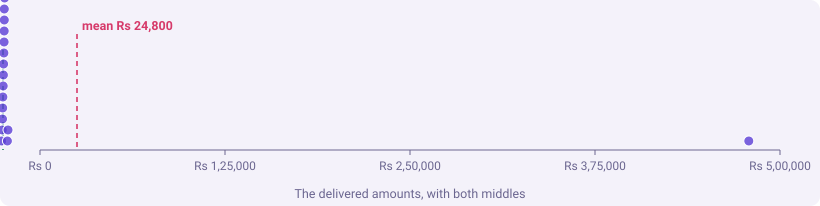

In [5]:
amounts = sorted(o["amount"] for o in delivered)
n = len(amounts)
mean_order = sum(amounts) / n
# TODO 4. Which expression is the median of the sorted list?
#   a) (amounts[n // 2 - 1] + amounts[n // 2]) / 2
#   b) amounts[n // 2 + 1]
#   c) amounts[n // 2]
#   d) sum(amounts) / n
median_order = amounts[n // 2]
# TODO 5. Which test counts an order as sitting above the mean?
#   a) amount > mean_order
#   b) amount > median_order
#   c) amount >= 0
#   d) amount < mean_order
above = 0
for amount in amounts:
    if amount > mean_order:
        above += 1
kit.stats([(kit.rupees(round(mean_order)), "delivered mean", "every delivered amount / the delivered orders"),
           (kit.rupees(median_order), "delivered median", "the middle of the sorted list"),
           (f"{above} of {n}", "above the mean", "the rest sit below")])
kit.strip(amounts, markers=[("mean", round(mean_order), "bad"), ("median", median_order, "good")],
          title="The delivered amounts, with both middles")

In [6]:
kit.check("the median has as many delivered amounts above it as below it",
          sum(a > median_order for a in amounts) == sum(a < median_order for a in amounts))
kit.check("the delivered mean sits more than ten times above the median", mean_order > 10 * median_order)
kit.check("at most one delivered order in ten sits above the mean", above <= n / 10)

**Why not the others.** TODO 4: a is the even-count rule, which here averages the 10th and 11th;
b is one place past the middle; d is the mean. TODO 5: b counts orders above the median, about
half by construction; c counts everything; d counts the other side.

**What happened.** The typical delivered order is the median, Rs 2,060; the mean is Rs 24,800,
with 1 of the 21 orders above it. The mean rose Rs 6,640 from the booked Rs 18,160 and the
median fell Rs 145, so the typical order held.

## Part 3. How much more must delivered consumer revenue bring, and what would a discount do to it?

At work, every growth plan and every promotion is sized in rupees before anyone funds it. As in
chapter 5, the plan is sized on the consumer view, the orders in the three consumer segments
Meera's plan concerns (Retail-Core, Retail-Plus and Student), here kept to the delivered orders.

**Write down:** the plan on delivered consumer revenue, what frequency alone asks of the same
customers, and what a 15 percent discount that lifts orders 10 percent does to delivered
consumer revenue.

question,answer
the plan on delivered consumer revenue,"Rs 40,790 to Rs 46,909, Rs 6,119 more"
orders per customer the plan needs from frequency alone,"1.11 to 1.28, +15% orders from the same customers"
delivered consumer revenue after the discount,"Rs 38,139, -6.5%"


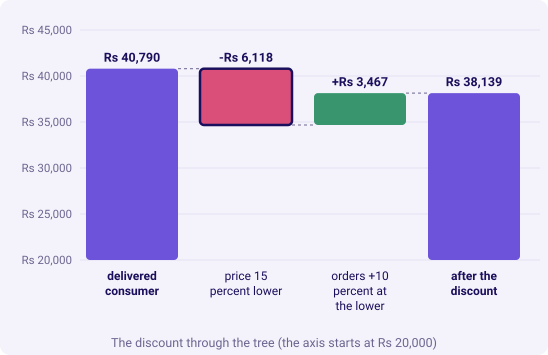

In [7]:
CONSUMER = ("Retail-Core", "Retail-Plus", "Student")        # the segments Meera's plan concerns
kept = [o for o in delivered if o["segment"] in CONSUMER]    # the delivered consumer view
kept_revenue = sum(o["amount"] for o in kept)
kept_customers = len({o["customer_id"] for o in kept})
plan = kept_revenue * 1.15
# TODO 6. If only frequency moves, how many delivered consumer orders must the same customers place?
#   a) len(kept) * 1.15
#   b) len(kept) + 15
#   c) len(kept) + 0.15
#   d) len(set(o["customer_id"] for o in kept)) * 1.15
needed_orders = len(kept) * 1.15
# TODO 7. A 15 percent discount lifts orders 10 percent. What multiplies delivered revenue?
#   a) 1 - 0.15 + 0.10
#   b) 0.85 * 1.10
#   c) 1.15 * 1.10
#   d) (1 - 0.15) * (1 - 0.10)
discount_factor = 0.85 * 1.10
after_discount = kept_revenue * discount_factor
kit.table(["question", "answer"],
          [("the plan on delivered consumer revenue",
            f"{kit.rupees(kept_revenue)} to {kit.rupees(int(plan + 0.5))}, {kit.rupees(int(plan + 0.5) - kept_revenue)} more"),
           ("orders per customer the plan needs from frequency alone",
            f"{len(kept) / kept_customers:.2f} to {needed_orders / kept_customers:.2f}, "
            f"{needed_orders / len(kept) - 1:+.0%} orders from the same customers"),
           ("delivered consumer revenue after the discount",
            f"{kit.rupees(round(after_discount))}, {discount_factor - 1:+.1%}")],
          caption="The plan and the discount on the delivered consumer view")
kit.bridge(("delivered consumer", kept_revenue),
           [("price 15 percent lower", -round(kept_revenue * 0.15)),
            ("orders +10 percent at the lower price", round(kept_revenue * 0.85 * 0.10))],
           end_label="after the discount", lit=(0,), lo=20000,
           title="The discount through the tree (the axis starts at Rs 20,000)")

In [8]:
kit.check("frequency alone reaches the plan", abs(needed_orders * (kept_revenue / len(kept)) - plan) < 1)
kit.check("the discount lowers delivered consumer revenue", after_discount < kept_revenue)
kit.check("the discount lands where the bridge's two moves land",
          abs(after_discount - (kept_revenue - kept_revenue * 0.15 + kept_revenue * 0.85 * 0.10)) < 1)

**Why not the others.** TODO 6: d is the customers answer; b adds 15 orders, a 75 percent lift;
c adds 0.15 of an order. TODO 7: a adds the two moves and reads a 5 percent fall where the tree
gives 6.5; c raises the price; d cuts orders instead of lifting them.

**What happened.** On the delivered consumer view, Rs 40,790, the plan is Rs 46,909, Rs 6,119
more. Frequency alone needs 15 percent more delivered orders from the same customers, orders per
customer from 1.11 to 1.28, and the discount takes the same Rs 40,790 to Rs 38,139, a 6.5
percent fall.

## Part 4. Which branch does Meera open first on delivered orders, once the window's edge is allowed for?

At work, a retention team calls a customer lapsed only after the usual gap between orders has
passed. Count the one-time buyers on delivered orders, then hold back the ones too recent to
judge, using chapter 6's median repeat gap of 45 days, measured on the 7 customers who came back
on booked orders.

**Write down:** delivered customers who bought once, how many of them are too recent, and the
branch.

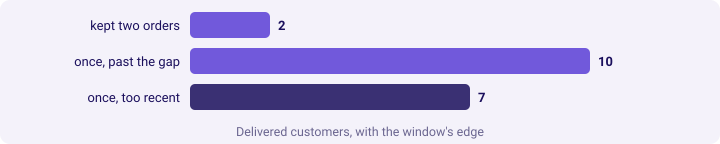

open first: frequency


In [9]:
firsts = {}
for order in delivered:
    firsts.setdefault(order["customer_id"], []).append(date.fromisoformat(order["order_date"]))
once = [cid for cid, days in firsts.items() if len(days) == 1]
typical_gap = 45                                   # chapter 6, from the booked repeat buyers
# TODO 8. Which test flags a one-time buyer as too recent to judge?
#   a) days_since > typical_gap
#   b) days_since < typical_gap
#   c) days_since == 0
#   d) typical_gap < 45
too_recent = 0
for cid in once:
    days_since = (end - firsts[cid][0]).days
    if days_since < typical_gap:
        too_recent += 1
# TODO 9. On delivered orders, which branch does Meera open first?
#   a) "customers"
#   b) "price"
#   c) "frequency"
#   d) "order value"
first_branch = "frequency"
kit.bars([("kept two orders", delivered_customers - len(once)), ("once, past the gap", len(once) - too_recent),
          ("once, too recent", too_recent)], lit=(2,), title="Delivered customers, with the window's edge")
print("open first:", first_branch)

In [10]:
kit.check("every delivered customer is counted once", len(firsts) == delivered_customers)
kit.check("the due-date route finds the same too-recent count",
          too_recent == sum(1 for cid in once if firsts[cid][0] + timedelta(days=typical_gap) > end))
kit.check("the one-time buyers outnumber the customers who kept two orders",
          len(once) > delivered_customers - len(once))

**Why not the others.** TODO 8: a flags the ones who had time; c catches only a same-day order;
d compares the gap with itself. TODO 9: a is marketing's branch, which one window cannot show
falling; b and d rest on fields this file lacks, items and prices, and d also leans on a mean
that sits far above the typical order.

**What happened.** 17 of the 19 delivered customers kept one order, 7 of them too recent to
judge, and only 2 kept two orders, so frequency stays first. The delivered view adds a leak: of
the 7 customers who came back, 4 lost that second order to a cancellation or a return.

## Part 5. What one sentence does Meera sign on delivered orders?

At work, an analysis ends as a sentence a stakeholder can sign. Write one sentence in chapter
6's four parts, on delivered orders: the evidence with its window and definition, the branch,
what one quarter cannot show, and what happens to the Rs 12 crore. Say what held from the booked
answer, and post it as text.

One sentence that holds: "On the 21 delivered orders from 1 July to 26 September, 19 customers
kept 1.11 orders each at a typical Rs 2,060, and 17 kept only one, 7 of them too recent to
judge, so frequency is still the branch to open first, with returns and cancellations on repeat
orders as the leak to fix; one quarter cannot show which branch moved, so hold the Rs 12 crore
until Tuesday's two quarters."

In [11]:
kit.table(["part", "booked (the chapters)", "delivered (this case)", "held?"],
          [("orders per customer", f"{BOOKED['orders per customer']:.2f}", f"{delivered_per_customer:.2f}",
            "held" if abs(delivered_per_customer - BOOKED["orders per customer"]) < 0.05 else "moved"),
           ("typical order", kit.rupees(BOOKED["typical order"]), kit.rupees(median_order),
            "held" if abs(median_order - BOOKED["typical order"]) < 200 else "moved"),
           ("one-time buyers too recent to judge", BOOKED["too recent"], f"{too_recent} of {len(once)}",
            "held" if too_recent > 0 else "moved"),
           ("branch", BOOKED["branch"], first_branch, "held" if first_branch == BOOKED["branch"] else "moved")],
          caption="What moved and what held")

part,booked (the chapters),delivered (this case),held?
orders per customer,1.30,1.11,moved
typical order,"Rs 2,205","Rs 2,060",held
one-time buyers too recent to judge,9 of 16,7 of 17,held
branch,frequency,frequency,held


## Did Meera's answer survive on the orders that stayed delivered?

It did. Frequency stays the branch to open first, orders per customer fell from 1.30 to 1.11,
and the typical order held at Rs 2,060 against Rs 2,205.

- How many customers stand behind the delivered orders? 19 customers placed the 21 delivered
  orders, 1.11 each, and 2 of them kept two.
- What does a typical delivered order look like? The median is Rs 2,060, and the mean is
  Rs 24,800 with 1 of the 21 orders above it.
- How much more must delivered consumer revenue bring? It must bring Rs 6,119 more, from
  Rs 40,790 to Rs 46,909; frequency alone needs 15 percent more orders from the same customers,
  and a 15 percent discount that lifts orders 10 percent takes revenue to Rs 38,139, a 6.5
  percent fall.
- Which branch comes first, once the window's edge is allowed for? Frequency does: 17 of 19
  kept one order, and 7 of those are too recent to judge.
- What does Meera sign? She signs the sentence above, with returns and cancellations on repeat
  orders named as the leak to fix.

In [12]:
kit.check_summary()
print("Next: the second case asks whether the channel view changes the branch.")

Next: the second case asks whether the channel view changes the branch.
